## 🌳 Árvore de Decisão — Resumo Essencial

### 📌 Escala dos dados
- Não precisa padronização ou normalização.
- Divide por regras do tipo: `feature <= valor`.
- Importa a ordem dos valores, não a escala.
- Não usa distância.

---

### 📌 Principal risco: Overfitting
A árvore pode:
- Crescer até Gini = 0
- Memorizar ruído
- Perder capacidade de generalização

**Controle de complexidade:**
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `ccp_alpha` (poda)

---

### 📌 Sensibilidade
- Sensível a ruído e outliers.
- Pequenas variações podem mudar a estrutura.
- Random Forest reduz essa instabilidade.

---

### 📌 Dados desbalanceados
- Pode favorecer classe majoritária.
- Accuracy pode enganar.

Avaliar com:
- Precision
- Recall
- F1-score
- Matriz de confusão

Usar se necessário:
- `class_weight="balanced"`

---

### 📌 Variáveis categóricas
- sklearn não aceita strings diretamente.
- Necessário encoding:
  - OneHotEncoder
  - LabelEncoder

---

### 🎯 Essência Técnica

✔ Baseada em regras  
✔ Alta interpretabilidade (se rasa)  
✔ Propensa a overfitting  
✔ Não depende de escala  
✔ Precisa controle de complexidade  

In [18]:
# =========================
# 1️⃣ IMPORTAR BIBLIOTECAS
# =========================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report


# =========================
# 2️⃣ IMPORTAR DATASET
# =========================
import kagglehub

# Download latest version
path = kagglehub.dataset_download("laotse/credit-risk-dataset")

print("Path to dataset files:", path)
df = pd.read_csv(f"{path}/credit_risk_dataset.csv")
display(df)

# # Transformar em DataFrame
# df = pd.DataFrame(iris.data, columns=iris.feature_names)
# df["target"] = iris.target

# print(df.head())

Path to dataset files: C:\Users\joth1\.cache\kagglehub\datasets\laotse\credit-risk-dataset\versions\1


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [19]:
df = df.rename(columns={
    "person_age": "idade",
    "person_income": "renda_anual",
    "person_home_ownership": "tipo_moradia",
    "person_emp_length": "tempo_emprego",
    "loan_intent": "finalidade_emprestimo",
    "loan_grade": "categoria_risco_emprestimo",
    "loan_amnt": "valor_emprestimo",
    "loan_int_rate": "taxa_juros",
    "loan_status": "status_emprestimo",
    "loan_percent_income": "percentual_renda_comprometido",
    "cb_person_default_on_file": "historico_inadimplencia",
    "cb_person_cred_hist_length": "tempo_historico_credito"
})
display(df)

,idade,renda_anual,tipo_moradia,tempo_emprego,finalidade_emprestimo,categoria_risco_emprestimo,valor_emprestimo,taxa_juros,status_emprestimo,percentual_renda_comprometido,historico_inadimplencia,tempo_historico_credito
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [20]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
# =========================
# 1️⃣ Separar target
# =========================

# Se historico_inadimplencia for o target
df["historico_inadimplencia"] = df["historico_inadimplencia"].map({"N": 0, "Y": 1})

# =========================
# 2️⃣ Definir colunas
# =========================

colunas_onehot = [
    "tipo_moradia",
    "finalidade_emprestimo"
]

coluna_ordinal = [
    "categoria_risco_emprestimo"
]

# Ordem correta do risco
ordem_risco = [['A','B','C','D','E','F','G']]
df

,idade,renda_anual,tipo_moradia,tempo_emprego,finalidade_emprestimo,categoria_risco_emprestimo,valor_emprestimo,taxa_juros,status_emprestimo,percentual_renda_comprometido,historico_inadimplencia,tempo_historico_credito
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,1,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,0,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,0,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,0,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,0,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,0,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,0,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,0,26


C:\Users\joth1\AppData\Local\Temp\ipykernel_11892\3863612259.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['tempo_emprego'].fillna(df['tempo_emprego'].mean(), inplace=True)
C:\Users\joth1\AppData\Local\Temp\ipykernel_11892\3863612259.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

Valores faltantes por coluna:
 idade                            0
renda_anual                      0
tipo_moradia                     0
tempo_emprego                    0
finalidade_emprestimo            0
categoria_risco_emprestimo       0
valor_emprestimo                 0
taxa_juros                       0
status_emprestimo                0
percentual_renda_comprometido    0
historico_inadimplencia          0
tempo_historico_credito          0
dtype: int64


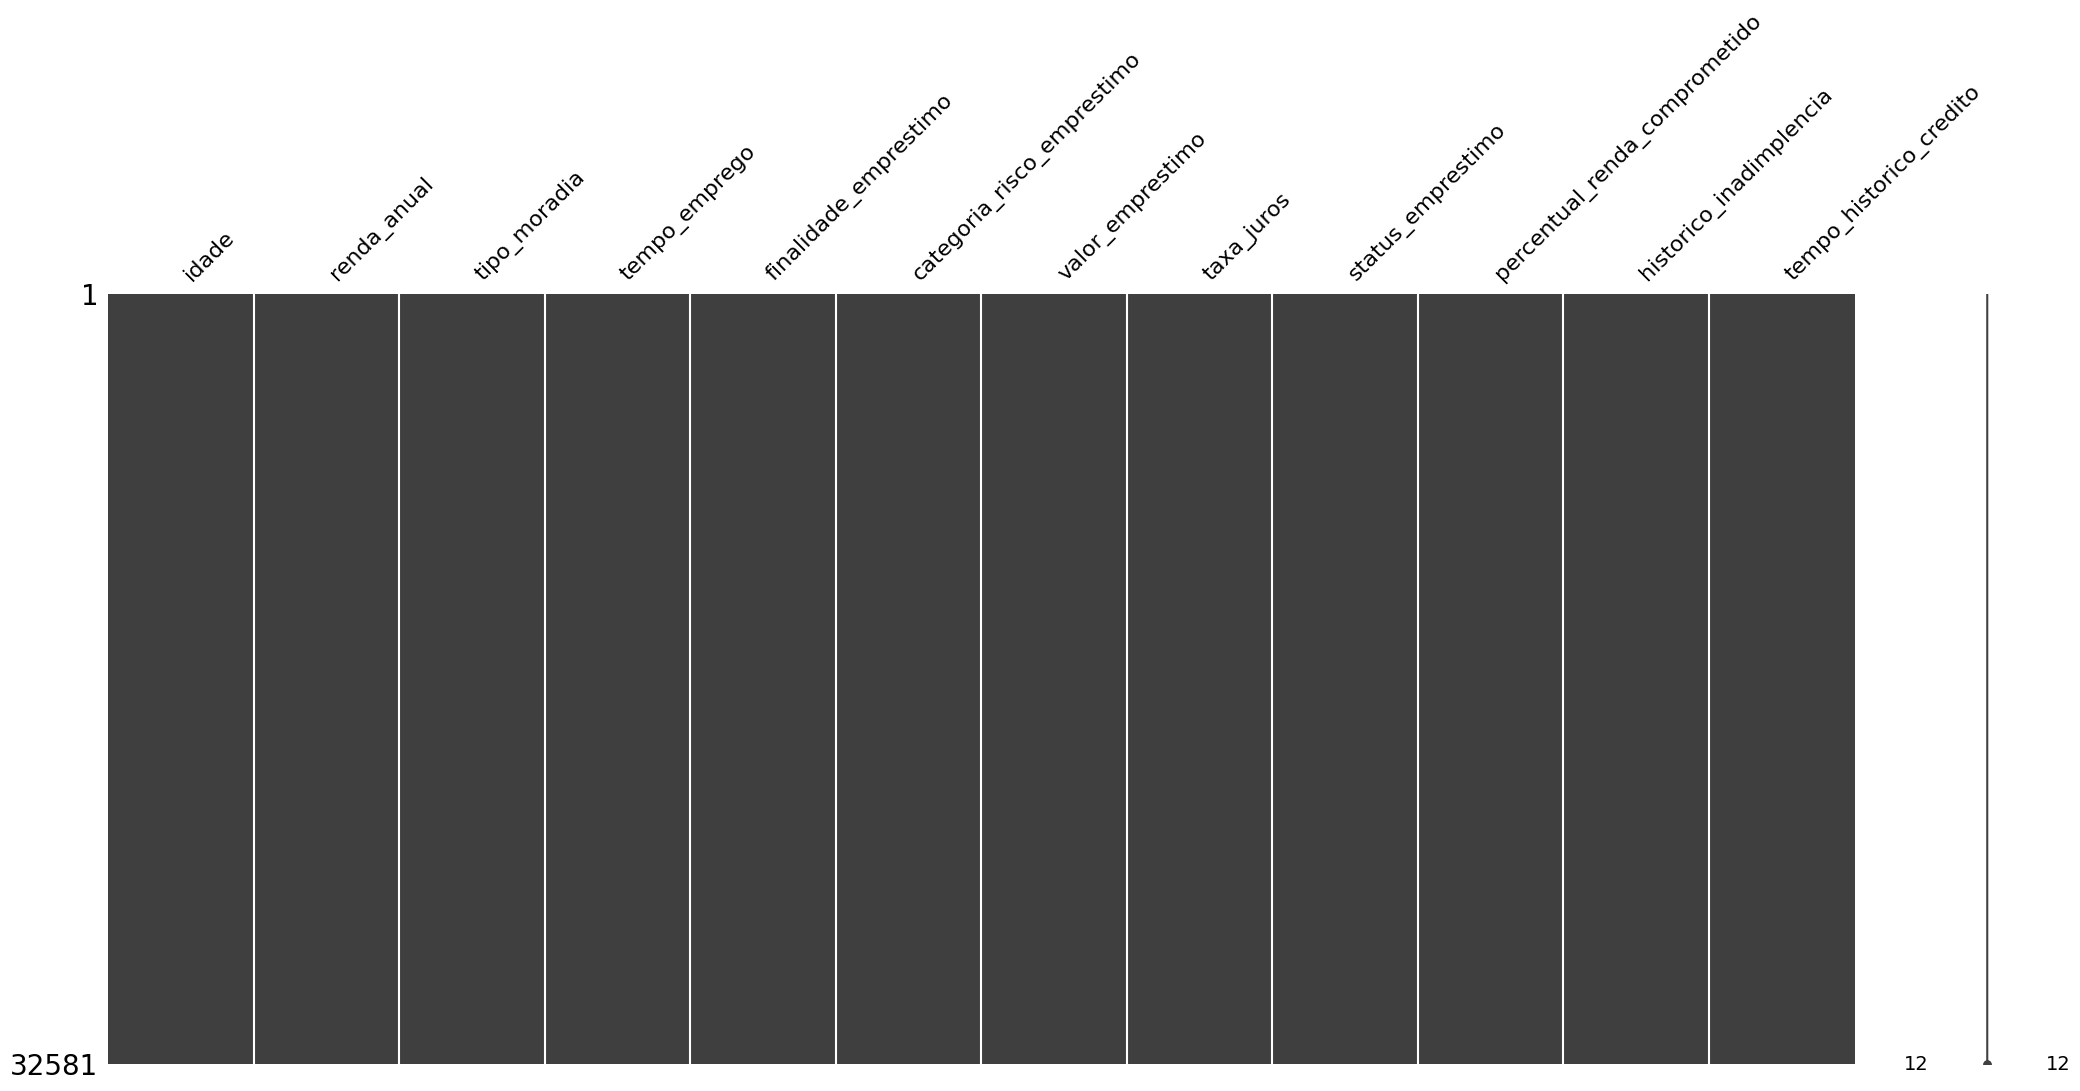

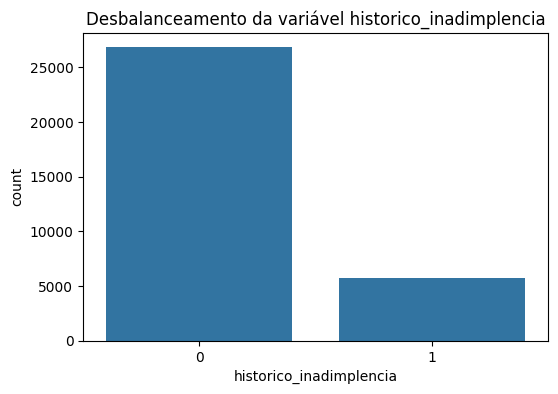

In [21]:
# Importando bibliotecas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# Supondo que a coluna seja 'tempo_emprestimo'
df['tempo_emprego'].fillna(df['tempo_emprego'].mean(), inplace=True)
df['taxa_juros'].fillna(df['taxa_juros'].mean(), inplace=True)



target = 'historico_inadimplencia'  # substitua pelo nome da sua variável alvo

# -------------------------------
# 1. Missing values
# -------------------------------
print("Valores faltantes por coluna:\n", df.isnull().sum())
# Visualização rápida de missing
msno.matrix(df)
plt.show()

# -------------------------------
# 2. Desbalanceamento da variável alvo
# -------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x=target, data=df)
plt.title(f'Desbalanceamento da variável {target}')
plt.show()

# -------------------------------
# 3. Relação das features com o alvo
# -------------------------------
# Separando numéricas e categóricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c != target]  # excluindo alvo
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


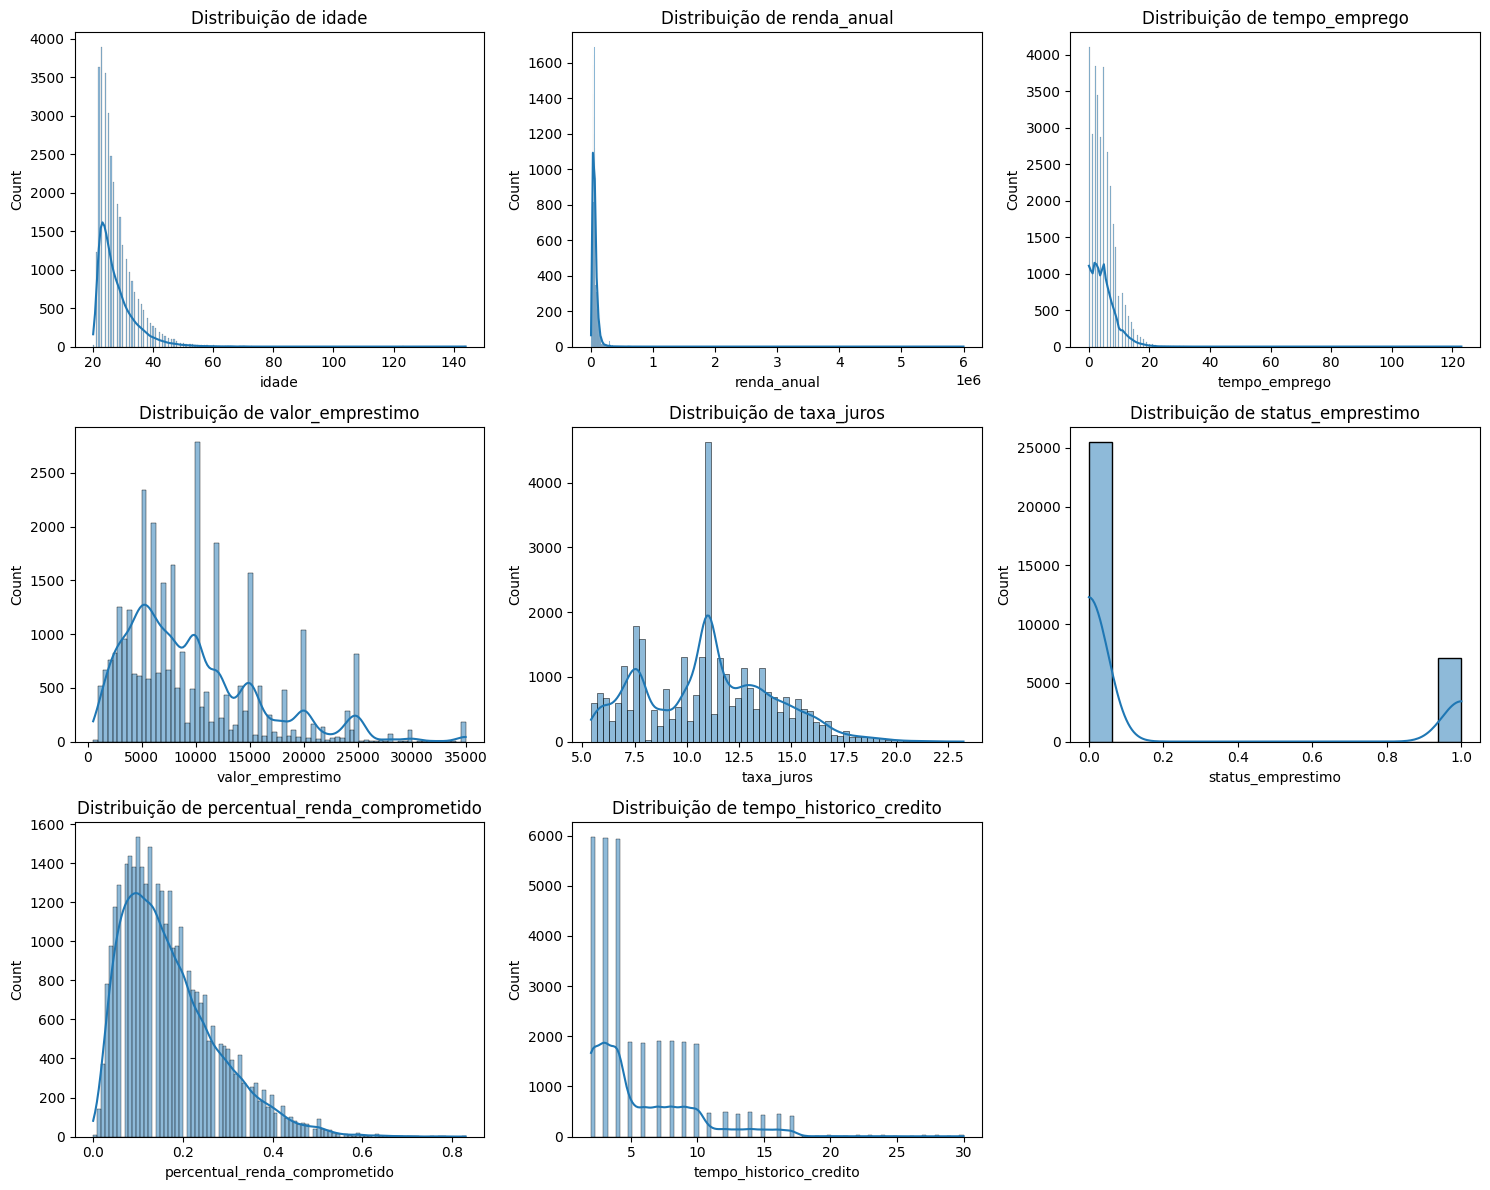

In [22]:
# Variáveis numéricas (excluindo o alvo)
num_cols = [c for c in df.select_dtypes(include=['int64','float64']).columns if c != target]

# Definindo grade de subplots
n_cols = 3  # quantos gráficos por linha
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # calcula linhas necessárias

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()  # facilita iterar

# Loop para criar os histogramas
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribuição de {col}')

# Remove eixos extras se houver
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

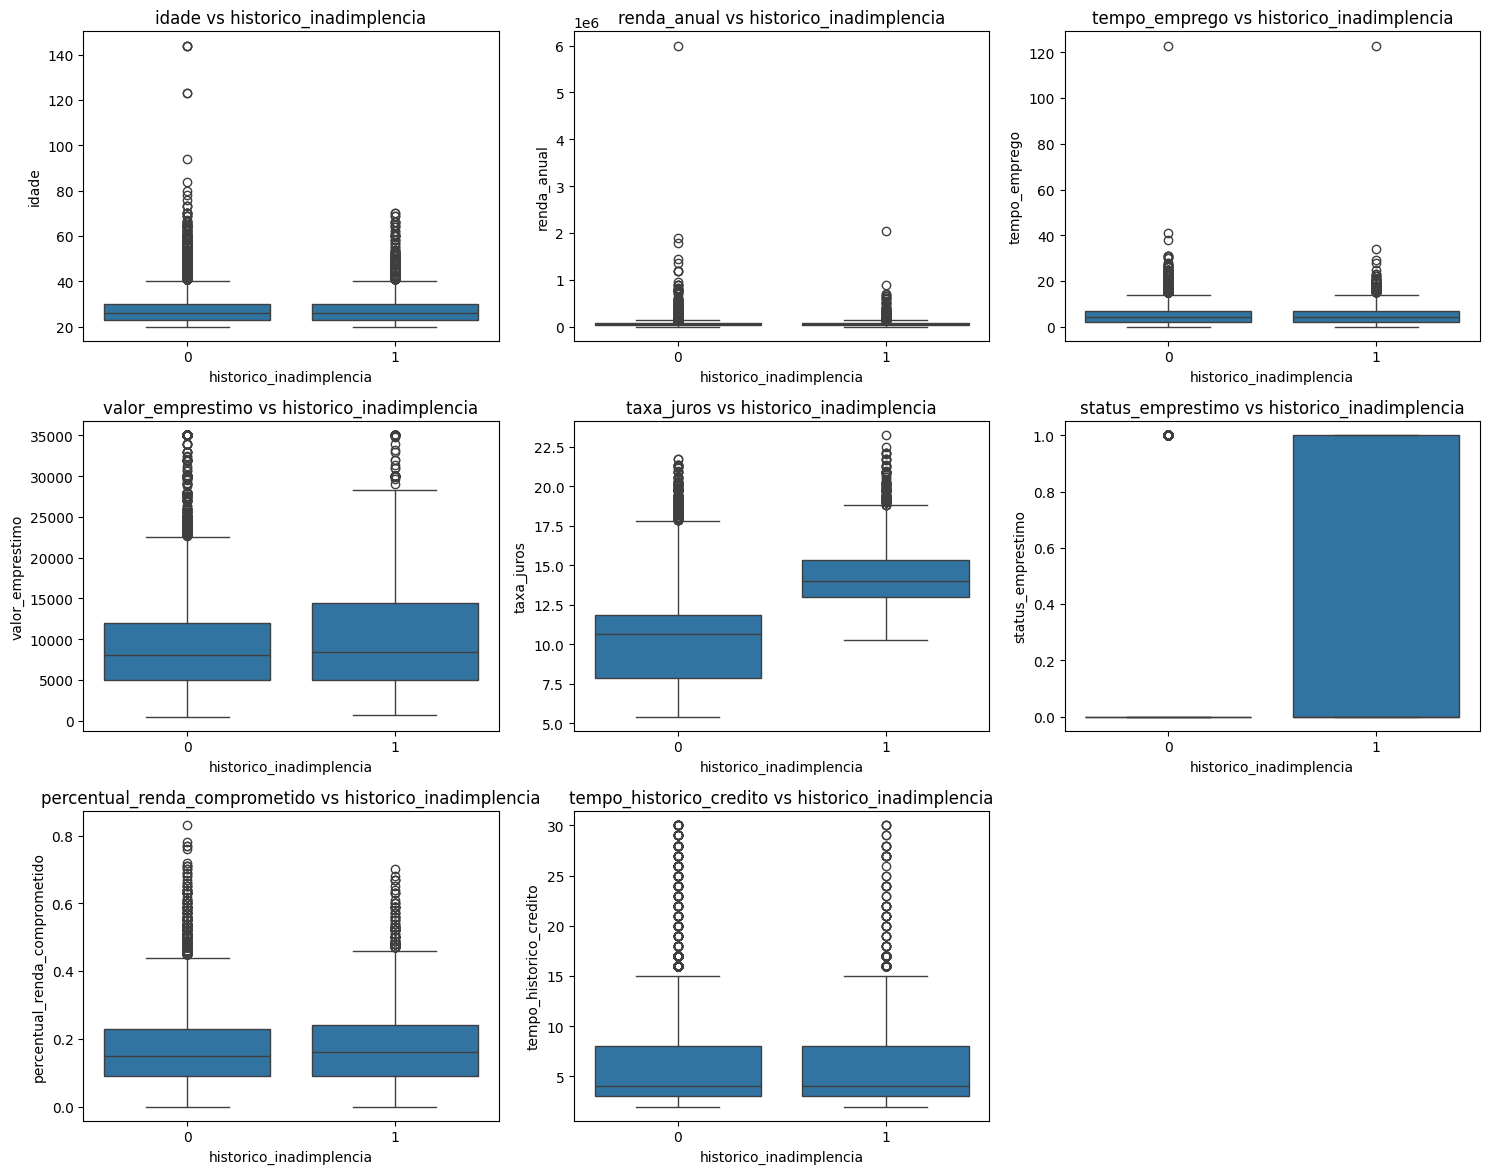

In [23]:
# Variáveis numéricas (excluindo o alvo)
num_cols = [c for c in df.select_dtypes(include=['int64','float64']).columns if c != target]

# Criando subplots (2 linhas x n colunas)
n_cols = 3  # número de gráficos por linha
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # calcula quantas linhas são necessárias

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()  # facilita iterar

for i, col in enumerate(num_cols):
    sns.boxplot(x=target, y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs {target}')

# Remove eixos extras se houver
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

c:\Users\joth1\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return bound(*args, **kwds)


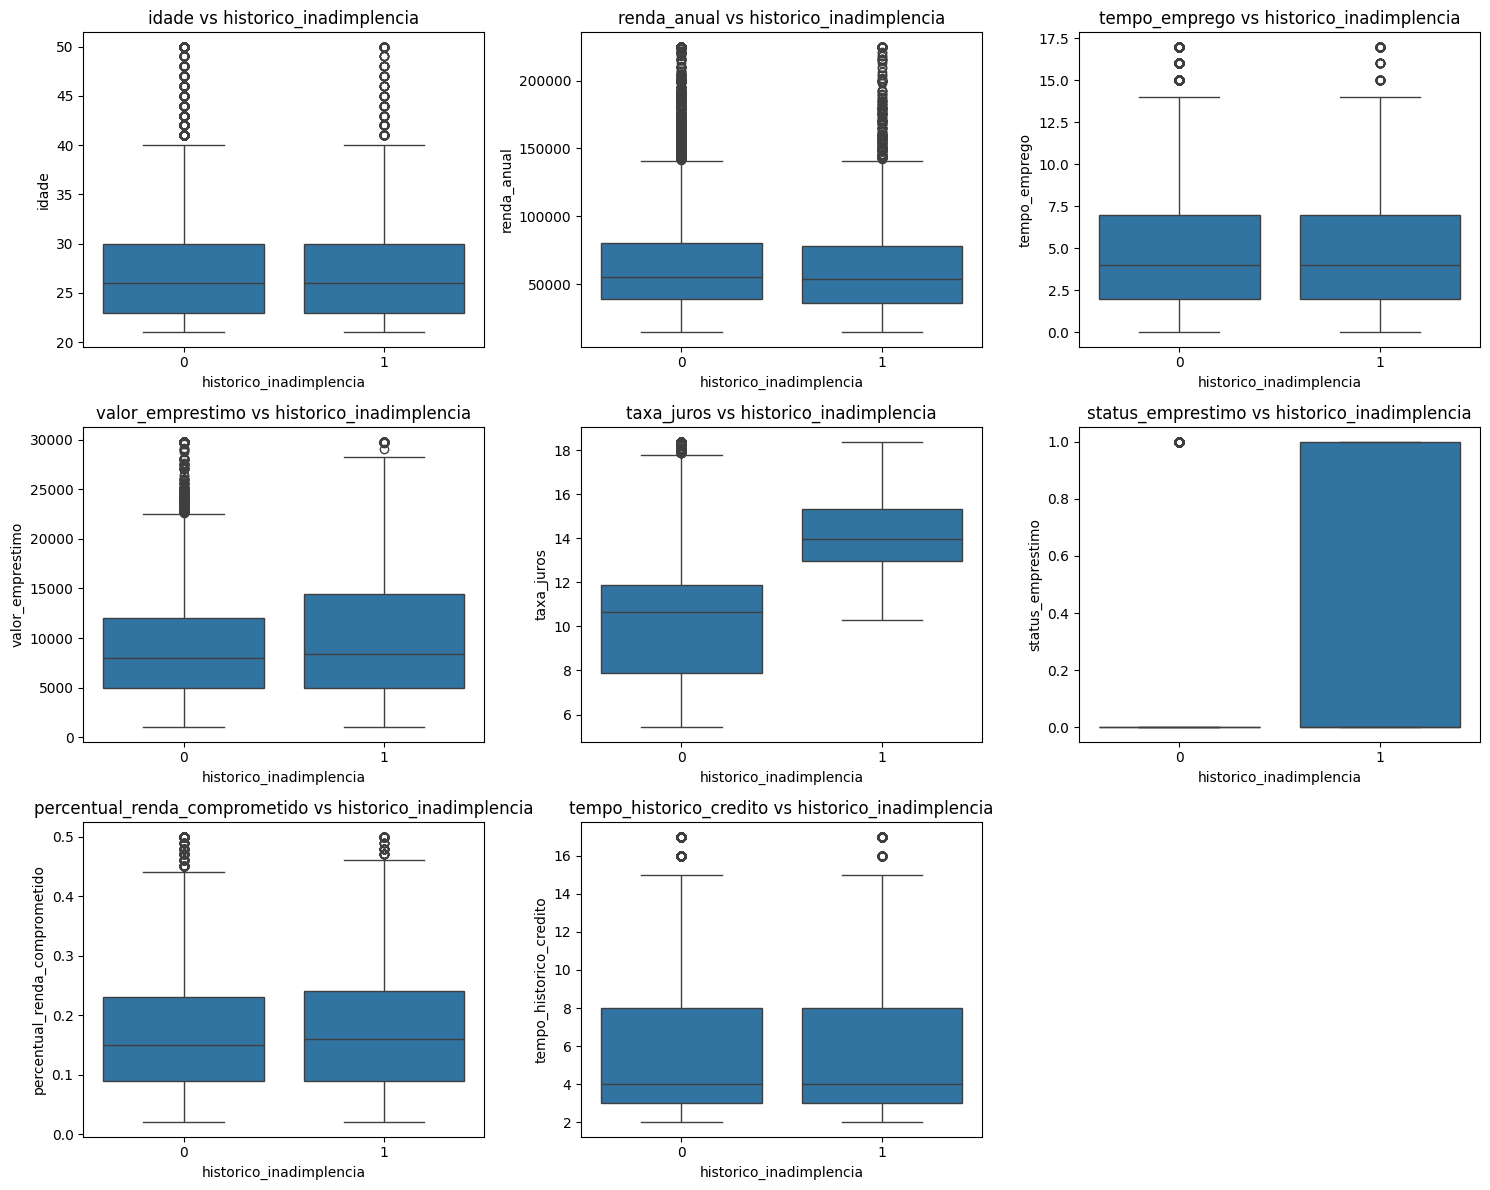

In [29]:
import numpy as np
num_cols = [c for c in num_cols if c != target]

for col in num_cols:
    limite_inferior = df[col].quantile(0.01)
    limite_superior = df[col].quantile(0.99)
    
    df[col] = np.clip(df[col], limite_inferior, limite_superior)
    
# Variáveis numéricas (excluindo o alvo)
num_cols = [c for c in df.select_dtypes(include=['int64','float64']).columns if c != target]

# Criando subplots (2 linhas x n colunas)
n_cols = 3  # número de gráficos por linha
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # calcula quantas linhas são necessárias

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()  # facilita iterar

for i, col in enumerate(num_cols):
    sns.boxplot(x=target, y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs {target}')

# Remove eixos extras se houver
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [61]:
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def avaliar_modelo(X, y, modelo, modo="simples", cv=5):
    
    if modo == "simples":
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )
        
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        
        print("Modo: Train/Test Split")
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print("\nClassification Report:\n")
        print(classification_report(y_test, y_pred))
        
        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(cm).plot()
        plt.show()
    
    
    elif modo == "cruzada":
        
        print("Modo: Validação Cruzada\n")
        
        scoring = {
            'accuracy': 'accuracy',
            'precision_macro': 'precision_macro',
            'recall_macro': 'recall_macro',
            'f1_macro': 'f1_macro'
        }
        
        resultados = cross_validate(modelo, X, y, cv=cv, scoring=scoring)
        
        print("Accuracy:", resultados['test_accuracy'].mean())
        print("Precision (macro):", resultados['test_precision_macro'].mean())
        print("Recall (macro):", resultados['test_recall_macro'].mean())
        print("F1 (macro):", resultados['test_f1_macro'].mean())
        
        # Predições fora do fold (correto para matriz)
        y_pred = cross_val_predict(modelo, X, y, cv=cv)
        
        print("\nClassification Report (CV completo):\n")
        print(classification_report(y, y_pred))
        
        cm = confusion_matrix(y, y_pred)
        ConfusionMatrixDisplay(cm).plot()
        plt.show()
    
    else:
        print("Modo inválido.")

Modo: Validação Cruzada

Accuracy: 0.8278754069373079
Precision (macro): 0.7532923219125987
Recall (macro): 0.8955136845273748
F1 (macro): 0.777792513116724

Classification Report (CV completo):

              precision    recall  f1-score   support

           0       1.00      0.79      0.88     26836
           1       0.51      1.00      0.67      5745

    accuracy                           0.83     32581
   macro avg       0.75      0.90      0.78     32581
weighted avg       0.91      0.83      0.85     32581



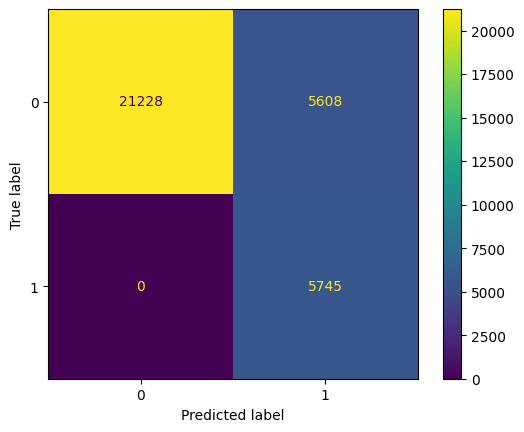

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier


preprocessador = ColumnTransformer( transformers=[ ("onehot", OneHotEncoder(drop="first"), colunas_onehot), ("ordinal", OrdinalEncoder(categories=ordem_risco), coluna_ordinal) ], remainder="passthrough" # Mantém colunas numéricas )
)

modelo = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("arvore", DecisionTreeClassifier(max_depth=5,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42)
)
])

# !pip install lightgbm
# from lightgbm import LGBMClassifier

# modelo = Pipeline(steps=[
#     ("preprocessamento", preprocessador),
#     ("lgbm", LGBMClassifier(
#         n_estimators=300,
#         learning_rate=0.05,
#         num_leaves=31,
#         class_weight="balanced",
#         random_state=42
#     ))
# ])


X = df.drop(columns=['historico_inadimplencia'])
y = df['historico_inadimplencia']

avaliar_modelo(X, y, modo="cruzada", modelo=modelo)

ordinal__categoria_risco_emprestimo: 0.9971
remainder__renda_anual: 0.0011
remainder__percentual_renda_comprometido: 0.0005
remainder__idade: 0.0004
remainder__taxa_juros: 0.0003
remainder__valor_emprestimo: 0.0002
remainder__tempo_emprego: 0.0001
remainder__tempo_historico_credito: 0.0001
onehot__finalidade_emprestimo_EDUCATION: 0.0000
remainder__status_emprestimo: 0.0000
onehot__tipo_moradia_OTHER: 0.0000
onehot__tipo_moradia_OWN: 0.0000
onehot__tipo_moradia_RENT: 0.0000
onehot__finalidade_emprestimo_HOMEIMPROVEMENT: 0.0000
onehot__finalidade_emprestimo_MEDICAL: 0.0000
onehot__finalidade_emprestimo_PERSONAL: 0.0000
onehot__finalidade_emprestimo_VENTURE: 0.0000


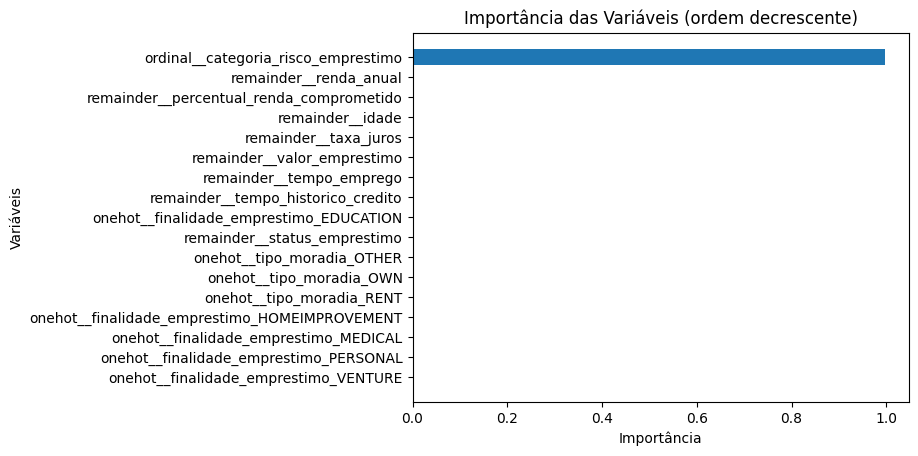

In [64]:
cv_result = cross_validate(
    modelo,
    X,
    y,
    cv=5,
    return_estimator=True
)

# Pega todos os modelos treinados
modelos = cv_result["estimator"]

importancias = np.array([
    m.named_steps["arvore"].feature_importances_
    for m in modelos
])

media_importancia = importancias.mean(axis=0)
desvio_importancia = importancias.std(axis=0)
# print("Média das importâncias:", media_importancia  )
# print("Desvio padrão das importâncias:", desvio_importancia)

preprocessador = modelos[0].named_steps["preprocessamento"]
nomes_features = preprocessador.get_feature_names_out()

ranking = sorted(zip(nomes_features, media_importancia),
                 key=lambda x: x[1],
                 reverse=True)

for nome, importancia in ranking:
    print(f"{nome}: {importancia:.4f}")


import matplotlib.pyplot as plt

# Garantindo que está do maior para o menor
ranking_ordenado = sorted(ranking, key=lambda x: x[1], reverse=True)

# Separando nomes e valores
nomes = [x[0] for x in ranking_ordenado]
importancias = [x[1] for x in ranking_ordenado]

plt.figure()
plt.barh(nomes, importancias)
plt.gca().invert_yaxis()  # deixa o maior no topo

plt.xlabel("Importância")
plt.ylabel("Variáveis")
plt.title("Importância das Variáveis (ordem decrescente)")

plt.show()

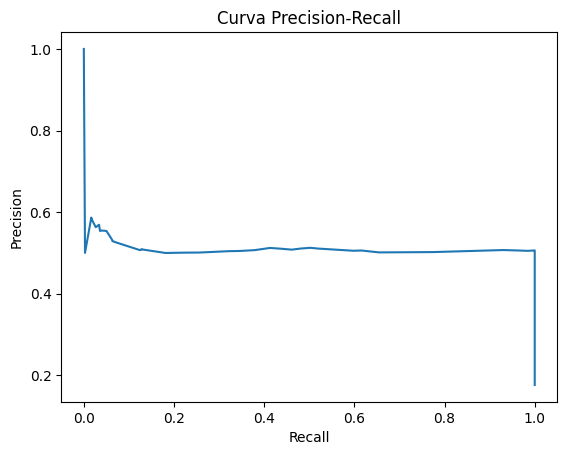

In [65]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Gerar probabilidades usando validação cruzada
y_scores = cross_val_predict(
    modelo, 
    X, 
    y, 
    cv=5, 
    method="predict_proba"
)

# Pegamos a probabilidade da classe positiva
# Para problema binário seria [:,1]
# Para Iris (3 classes) precisamos escolher uma classe específica
classe_interesse = 1
y_scores_classe = y_scores[:, classe_interesse]

# Criar curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(
    (y == classe_interesse).astype(int), 
    y_scores_classe
)

# Plotar gráfico
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.show()

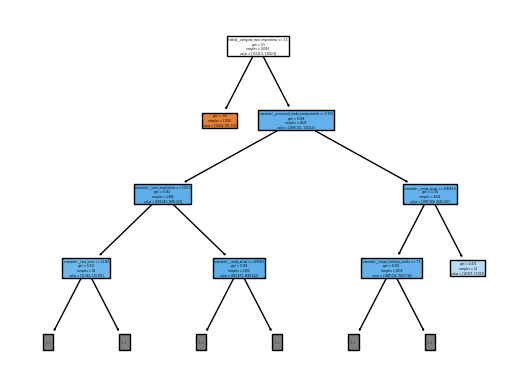

In [ ]:
modelo_fold = modelos[0]  # pega o primeiro fold
arvore = modelo_fold.named_steps["arvore"]
nomes_features = modelo_fold.named_steps["preprocessamento"].get_feature_names_out()
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_tree(
    arvore,
    feature_names=nomes_features,
    filled=True,
    
    max_depth=3
)

plt.show()